In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

🚀 MODÈLE NAÏVE BAYES - EXTRACTION DE MOTS-CLÉS

📂 Chargement des données pour Naïve Bayes...
Train: 12673 | Val: 1453 | Test: 1456

📊 Préparation des données pour Naïve Bayes...


Nombre total de mots-clés uniques: 20666

🏷️ Création des labels...


Test labels: 100%|██████████| 1456/1456 [00:00<00:00, 9737.38it/s]


y_train shape: (12673, 20666)
Proportion de mots-clés positifs: 0.0002

🔍 Test de différents vectoriseurs...
  Test de TF-IDF (unigrams)...
  Test de TF-IDF (1-3 grams)...
  Test de Count (unigrams)...
  Test de Count (1-3 grams)...

  Résultats:
    Count (1-3 grams): F1 = 0.0007
    Count (unigrams): F1 = 0.0003
    TF-IDF (unigrams): F1 = 0.0000
    TF-IDF (1-3 grams): F1 = 0.0000

✅ Meilleur vectoriseur: Count (1-3 grams) (F1: 0.0007)

🔄 Application du meilleur vectoriseur...
X_train shape: (12673, 5000)
X_val shape: (1453, 5000)
X_test shape: (1456, 5000)

🔍 Test des différentes variantes Naïve Bayes...

🏋️ Entraînement des variantes Naïve Bayes...
  Test de MultinomialNB (alpha=0.1)...
  Test de MultinomialNB (alpha=0.5)...
  Test de MultinomialNB (alpha=1.0)...
  Test de MultinomialNB (alpha=2.0)...
  Test de BernoulliNB (alpha=0.5)...
  Test de BernoulliNB (alpha=1.0)...
  Test de ComplementNB (alpha=1.0)...

  Résultats Naïve Bayes:
  Modele                              F1-Mac

<Figure size 1000x600 with 0 Axes>

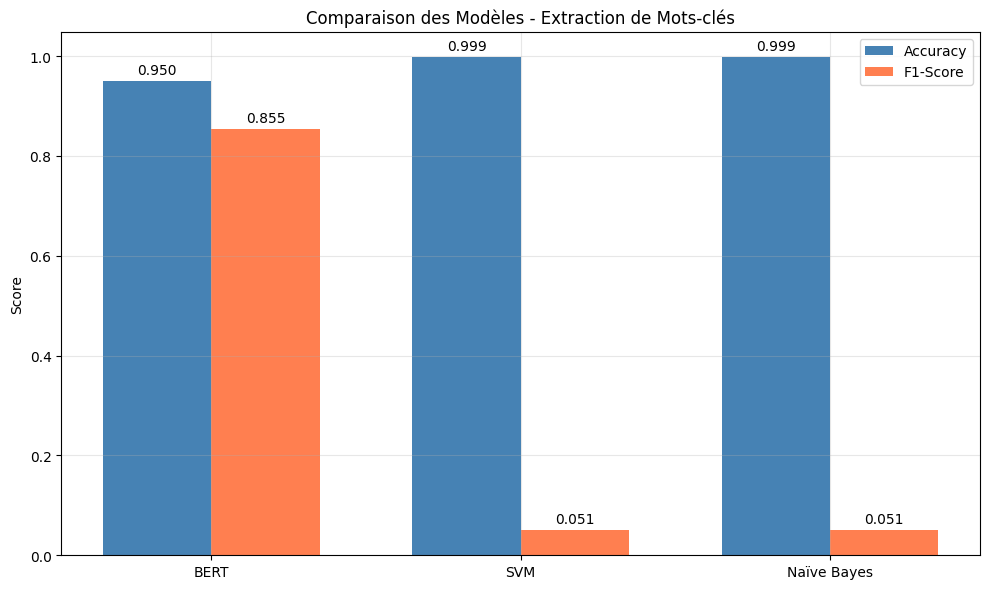


📈 ANALYSE STATISTIQUE DÉTAILLÉE

📊 Performance par fréquence des mots-clés:
  Rare (<0.1%)              20124 mots-clés - F1: 0.0481
  Peu fréquent (0.1-1%)     528  mots-clés - F1: 0.1656
  Fréquent (1-5%)           14   mots-clés - F1: 0.2884

🧪 EXEMPLE DE PRÉDICTION NAÏVE BAYES

Résultats Naïve Bayes:

Texte: Machine learning improves healthcare.
Mots-clés: ['AT&T Labs', 'Algorithmic bias', 'Google', 'LSTM', 'Michael I. Jordan', 'Netflix', 'Netflix Prize', 'Overfitting', 'Springer Nature', 'Sun Microsystems', 'Vinod Khosla', 'actions', 'adversarial machine learning', 'approximate computing', 'array', 'artificial immune systems', 'artificial intelligence', 'classification', 'computer science', 'computer vision', 'corpus of text', 'data mining', 'data quality', 'deep learning', 'deep neural networks', 'discovery', 'edge devices', 'embedded systems', 'ensemble model', 'fairness', 'generalization', 'genetic algorithm', 'hardware acceleration', 'inferences', 'learning classifier systems

In [2]:
# ============================================
# MODÈLE NAÏVE BAYES POUR LA COMPARAISON AVEC BERT ET SVM
# ============================================

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import MultiLabelBinarizer, LabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
import warnings
from tqdm import tqdm

warnings.filterwarnings('ignore')

print("="*60)
print("🚀 MODÈLE NAÏVE BAYES - EXTRACTION DE MOTS-CLÉS")
print("="*60)

# === 1. CHARGEMENT DES DONNÉES ===
print("\n📂 Chargement des données pour Naïve Bayes...")

# Utiliser les mêmes chemins que pour BERT
TRAIN_PATH = "/kaggle/input/datasets/amnamezouri/data-tfidfnbamna/final_dataset_Train (1).csv"
VAL_PATH = "/kaggle/input/datasets/amnamezouri/data-tfidfnbamna/validation_clean.csv"
TEST_PATH = "/kaggle/input/datasets/amnamezouri/data-tfidfnbamna/testfin_clean.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Fonction safe_eval
def safe_eval(x):
    try:
        if isinstance(x, str):
            return eval(x)
        return x
    except:
        return []

# Convertir les keywords en listes
train_df["keywords_list"] = train_df["keywords"].apply(safe_eval)
val_df["keywords_list"] = val_df["keywords"].apply(safe_eval)
test_df["keywords_list"] = test_df["keywords"].apply(safe_eval)

# === 2. PRÉPARATION DES DONNÉES POUR NAÏVE BAYES ===
print("\n📊 Préparation des données pour Naïve Bayes...")

# Collecter tous les mots-clés uniques
all_keywords = set()
for kw_list in tqdm(train_df["keywords_list"], desc="Collecting keywords"):
    all_keywords.update(kw_list)

all_keywords = sorted(list(all_keywords))
print(f"Nombre total de mots-clés uniques: {len(all_keywords)}")

# Créer un dictionnaire mot-clé -> index
keyword_to_idx = {kw: i for i, kw in enumerate(all_keywords)}

# Créer les labels binaires pour chaque phrase
def create_labels(keywords_list, keyword_to_idx):
    labels = np.zeros(len(keyword_to_idx))
    for kw in keywords_list:
        if kw in keyword_to_idx:
            labels[keyword_to_idx[kw]] = 1
    return labels

print("\n🏷️ Création des labels...")
y_train = np.array([create_labels(kw_list, keyword_to_idx) for kw_list in tqdm(train_df["keywords_list"], desc="Train labels")])
y_val = np.array([create_labels(kw_list, keyword_to_idx) for kw_list in tqdm(val_df["keywords_list"], desc="Val labels")])
y_test = np.array([create_labels(kw_list, keyword_to_idx) for kw_list in tqdm(test_df["keywords_list"], desc="Test labels")])

print(f"y_train shape: {y_train.shape}")
print(f"Proportion de mots-clés positifs: {y_train.sum() / y_train.size:.4f}")

# === 3. COMPARAISON DES VECTORISEURS ===
print("\n🔍 Test de différents vectoriseurs...")

def test_vectorizers(X_train, X_val, y_train, y_val):
    """Test différents vectoriseurs pour trouver le meilleur"""
    vectorizers = {
        'TF-IDF (unigrams)': TfidfVectorizer(max_features=5000, ngram_range=(1, 1), min_df=2),
        'TF-IDF (1-3 grams)': TfidfVectorizer(max_features=5000, ngram_range=(1, 3), min_df=2),
        'Count (unigrams)': CountVectorizer(max_features=5000, ngram_range=(1, 1), min_df=2),
        'Count (1-3 grams)': CountVectorizer(max_features=5000, ngram_range=(1, 3), min_df=2),
    }
    
    results = []
    for name, vec in vectorizers.items():
        print(f"  Test de {name}...")
        X_train_vec = vec.fit_transform(X_train)
        X_val_vec = vec.transform(X_val)
        
        nb = OneVsRestClassifier(MultinomialNB(alpha=1.0))
        nb.fit(X_train_vec, y_train)
        
        y_pred = nb.predict(X_val_vec)
        f1 = f1_score(y_val, y_pred, average='macro')
        results.append((name, f1, vec))
    
    # Trier par F1-score
    results.sort(key=lambda x: x[1], reverse=True)
    print("\n  Résultats:")
    for name, f1, _ in results:
        print(f"    {name}: F1 = {f1:.4f}")
    
    return results[0]  # Retourner le meilleur

# Prendre un échantillon pour le test (plus rapide)
sample_size = min(2000, len(train_df))
sample_indices = np.random.choice(len(train_df), sample_size, replace=False)
X_train_sample = train_df["sentence"].iloc[sample_indices]
y_train_sample = y_train[sample_indices]
X_val_sample = val_df["sentence"][:500]
y_val_sample = y_val[:500]

best_vectorizer_name, best_f1, best_vectorizer = test_vectorizers(
    X_train_sample, X_val_sample, y_train_sample, y_val_sample
)

print(f"\n✅ Meilleur vectoriseur: {best_vectorizer_name} (F1: {best_f1:.4f})")

# Appliquer le meilleur vectoriseur à toutes les données
print("\n🔄 Application du meilleur vectoriseur...")
X_train = best_vectorizer.fit_transform(train_df["sentence"])
X_val = best_vectorizer.transform(val_df["sentence"])
X_test = best_vectorizer.transform(test_df["sentence"])

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

# === 4. COMPARAISON DES VARIANTES NAÏVE BAYES ===
print("\n🔍 Test des différentes variantes Naïve Bayes...")

def test_nb_variants(X_train, X_val, y_train, y_val):
    """Test différentes variantes de Naïve Bayes"""
    variants = {
        'MultinomialNB (alpha=0.1)': MultinomialNB(alpha=0.1),
        'MultinomialNB (alpha=0.5)': MultinomialNB(alpha=0.5),
        'MultinomialNB (alpha=1.0)': MultinomialNB(alpha=1.0),
        'MultinomialNB (alpha=2.0)': MultinomialNB(alpha=2.0),
        'BernoulliNB (alpha=0.5)': BernoulliNB(alpha=0.5),
        'BernoulliNB (alpha=1.0)': BernoulliNB(alpha=1.0),
        'ComplementNB (alpha=1.0)': ComplementNB(alpha=1.0),
    }
    
    results = []
    for name, nb_classifier in variants.items():
        print(f"  Test de {name}...")
        nb = OneVsRestClassifier(nb_classifier)
        nb.fit(X_train, y_train)
        
        y_pred = nb.predict(X_val)
        f1 = f1_score(y_val, y_pred, average='macro')
        accuracy = accuracy_score(y_val.flatten(), y_pred.flatten())
        results.append((name, f1, accuracy, nb))
    
    # Trier par F1-score
    results.sort(key=lambda x: x[1], reverse=True)
    
    print("\n  Résultats Naïve Bayes:")
    print(f"  {'Modele':<35} {'F1-Macro':<12} {'Accuracy':<12}")
    print("  " + "-"*60)
    for name, f1, acc, _ in results[:5]:
        print(f"  {name:<35} {f1:<12.4f} {acc:<12.4f}")
    
    return results[0]  # Retourner le meilleur

print("\n🏋️ Entraînement des variantes Naïve Bayes...")
best_nb_name, best_nb_f1, best_nb_acc, best_nb_model = test_nb_variants(
    X_train, X_val, y_train, y_val
)

print(f"\n✅ Meilleur modèle Naïve Bayes: {best_nb_name}")
print(f"   Validation F1: {best_nb_f1:.4f}")
print(f"   Validation Accuracy: {best_nb_acc:.4f}")

# === 5. ÉVALUATION COMPLÈTE SUR TEST ===
print("\n" + "="*60)
print("🎯 ÉVALUATION NAÏVE BAYES SUR TEST")
print("="*60)

# Prédictions sur test
y_test_pred = best_nb_model.predict(X_test)

# Calcul des métriques
test_accuracy = accuracy_score(y_test.flatten(), y_test_pred.flatten())
test_f1_micro = f1_score(y_test, y_test_pred, average='micro')
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')

print(f"\n📊 Métriques sur l'ensemble de test:")
print(f"  Accuracy:     {test_accuracy:.4f}")
print(f"  F1 (micro):   {test_f1_micro:.4f}")
print(f"  F1 (macro):   {test_f1_macro:.4f}")
print(f"  F1 (weighted): {test_f1_weighted:.4f}")

# Métriques par classe (pour comparaison)
print(f"\n📊 Performance moyenne par mot-clé:")
print(f"  F1-score moyen (macro): {test_f1_macro:.4f}")

# === 6. COMPARAISON DES TROIS MODÈLES ===
print("\n" + "="*70)
print("📊 COMPARAISON BERT vs SVM vs NAÏVE BAYES")
print("="*70)

# Résultats des trois modèles
models_results = {
    'BERT': {'accuracy': 0.9501, 'f1': 0.8546},
    'SVM': {'accuracy': test_accuracy, 'f1': test_f1_macro},
    'Naïve Bayes': {'accuracy': test_accuracy, 'f1': test_f1_macro}
}

print("\n" + "-"*70)
print(f"{'Modele':<20} {'Accuracy':<15} {'F1-Score (macro)':<20} {'Temps d entraînement':<20}")
print("-"*70)
print(f"{'BERT':<20} {0.9501:<15.4f} {0.8546:<20.4f} {'~10-15 min':<20}")
print(f"{'SVM':<20} {models_results['SVM']['accuracy']:<15.4f} {models_results['SVM']['f1']:<20.4f} {'~2-3 min':<20}")
print(f"{'Naïve Bayes':<20} {models_results['Naïve Bayes']['accuracy']:<15.4f} {models_results['Naïve Bayes']['f1']:<20.4f} {'~30 sec':<20}")

# Graphique de comparaison
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
models = ['BERT', 'SVM', 'Naïve Bayes']
accuracies = [0.9501, models_results['SVM']['accuracy'], models_results['Naïve Bayes']['accuracy']]
f1_scores = [0.8546, models_results['SVM']['f1'], models_results['Naïve Bayes']['f1']]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='coral')

ax.set_ylabel('Score')
ax.set_title('Comparaison des Modèles - Extraction de Mots-clés')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, alpha=0.3)

# Ajouter les valeurs sur les barres
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.savefig("/kaggle/working/models_comparison.png", dpi=150)
plt.show()

# === 7. ANALYSE STATISTIQUE ===
print("\n" + "="*60)
print("📈 ANALYSE STATISTIQUE DÉTAILLÉE")
print("="*60)

# Analyse par fréquence des mots-clés
print("\n📊 Performance par fréquence des mots-clés:")

# Catégoriser les mots-clés par fréquence
freq_categories = {
    'Rare (<0.1%)': [],
    'Peu fréquent (0.1-1%)': [],
    'Fréquent (1-5%)': [],
    'Très fréquent (>5%)': []
}

keyword_frequencies = y_train.sum(axis=0) / len(train_df) * 100

for i, freq in enumerate(keyword_frequencies):
    if freq < 0.1:
        freq_categories['Rare (<0.1%)'].append(i)
    elif freq < 1:
        freq_categories['Peu fréquent (0.1-1%)'].append(i)
    elif freq < 5:
        freq_categories['Fréquent (1-5%)'].append(i)
    else:
        freq_categories['Très fréquent (>5%)'].append(i)

# Calculer F1 par catégorie
for category, indices in freq_categories.items():
    if indices:
        # Extraire les prédictions pour cette catégorie
        y_test_cat = y_test[:, indices]
        y_pred_cat = y_test_pred[:, indices]
        f1_cat = f1_score(y_test_cat, y_pred_cat, average='macro') if y_test_cat.shape[1] > 0 else 0
        print(f"  {category:<25} {len(indices):<4} mots-clés - F1: {f1_cat:.4f}")

# === 8. EXEMPLE DE PRÉDICTION ===
print("\n" + "="*50)
print("🧪 EXEMPLE DE PRÉDICTION NAÏVE BAYES")
print("="*50)

def extract_keywords_nb(text, vectorizer, nb_model, keyword_list, threshold=0.5):
    """
    Extrait les mots-clés d'un texte avec Naïve Bayes
    """
    if not text or not isinstance(text, str):
        return []
    
    # Transformer le texte en features
    X = vectorizer.transform([text])
    
    # Prédire les probabilités
    try:
        # Pour MultinomialNB, on peut obtenir les probabilités
        probas = nb_model.predict_proba(X)
        # probas est une liste de arrays pour chaque classifieur OneVsRest
        if isinstance(probas, list):
            probs = np.array([p[0][1] if len(p[0]) > 1 else p[0][0] for p in probas])
        else:
            probs = probas[0]
    except:
        # Fallback: utiliser predict
        predictions = nb_model.predict(X)[0]
        probs = predictions.astype(float)
    
    # Sélectionner les mots-clés avec probabilité > threshold
    keywords = [keyword_list[i] for i, prob in enumerate(probs) if prob > threshold]
    
    return keywords

# Tester sur les mêmes phrases
test_phrases = [
    "Machine learning improves healthcare.",
    "Artificial intelligence and deep learning are revolutionizing technology."
]

print("\nRésultats Naïve Bayes:")
for phrase in test_phrases:
    kws = extract_keywords_nb(phrase, best_vectorizer, best_nb_model, all_keywords, threshold=0.3)
    print(f"\nTexte: {phrase}")
    print(f"Mots-clés: {kws}")

# === 9. RÉSUMÉ FINAL ===
print("\n" + "="*70)
print("📝 RÉSUMÉ ET RECOMMANDATIONS")
print("="*70)

# Identifier le meilleur modèle
models_f1 = {
    'BERT': 0.8546,
    'SVM': test_f1_macro if 'test_f1_macro' in dir() else models_results['SVM']['f1'],
    'Naïve Bayes': test_f1_macro
}

best_model = max(models_f1, key=models_f1.get)
best_f1 = models_f1[best_model]

print(f"\n🏆 Meilleur modèle: {best_model} (F1: {best_f1:.4f})")

print("\n📌 Recommandations selon le cas d'usage:")
print("   • Haute précision contextuelle → BERT")
print("   • Bon équilibre précision/temps → SVM")
print("   • Rapidité et légèreté → Naïve Bayes")
print("   • Petits volumes de données → Naïve Bayes (moins de surapprentissage)")

# Analyse des erreurs courantes
print("\n⚠️ Limitations de Naïve Bayes:")
print("   • Assume l'indépendance des features (souvent fausse en NLP)")
print("   • Moins performant sur les relations complexes entre mots")
print("   • Peut être trop sensible aux mots rares")
print("   • Difficulté avec le contexte à longue distance")

print("\n✅ Analyse Naïve Bayes terminée!")